In [ ]:
import json

In [2]:
import json

with open('llama_8b_finetune_format_v2_qwen3_8b_judgement.jsonl', 'r') as f:
    llama = [json.loads(line) for line in f]

with open('llama_8b_sft_lora_finetune_format_v2_qwen3_8b_judgement.jsonl', 'r') as f:
    llama_sft_lora = [json.loads(line) for line in f]


In [3]:
llama[0]

{'epi_pk': '01JXWFYST1AY4PCRY7J9TCXP3A',
 'turn_idx': 0,
 'epi_tag': 'llama_8b_finetune_format_v2',
 'epi_messages': 'Turn #0: Zoe Taylor said: "I think we should focus on securing the Balkans and denying Italy any opportunities to expand. What are your thoughts on this?"\n',
 '1gamemove.yes': 1,
 '2reasoning.yes': 0,
 '3rapport.yes': 0,
 '3a_apologies.yes': 0,
 '3a_compliment.yes': 0,
 '3a_personalthoughts.yes': 0,
 '3a_reassurance.yes': 0,
 '4shareinformation.yes': 1}

In [4]:
import pandas as pd

# 把它们变成dataframe
df_llama = pd.DataFrame(llama)
df_llama_sft_lora = pd.DataFrame(llama_sft_lora)

# 根据 epi_pk 和 turn_idx 共同索引，只保留两个dataframe都存在的行
common = pd.merge(
    df_llama,
    df_llama_sft_lora,
    on=['epi_pk', 'turn_idx'],
    # suffixes=('_llama', '_llama_sft_lora')
)

# 如果你想要分别得到两个dataframe中只包含共同索引的部分，可以这样：
df_llama_common = df_llama.merge(common[['epi_pk', 'turn_idx']], on=['epi_pk', 'turn_idx'])
df_llama_sft_lora_common = df_llama_sft_lora.merge(common[['epi_pk', 'turn_idx']], on=['epi_pk', 'turn_idx'])

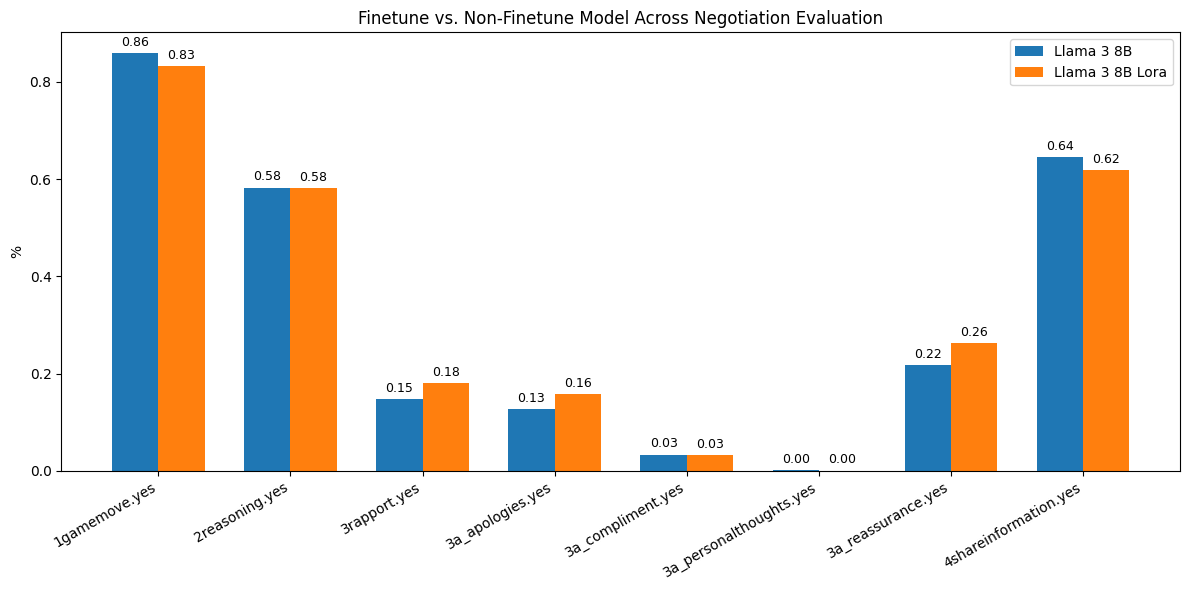

In [9]:
# 画一个bar table, 比较llama 3 8b和llama 3 8b lora在8个features上1的比例

import matplotlib.pyplot as plt
import numpy as np

features = [
    '1gamemove.yes',
    '2reasoning.yes',
    '3rapport.yes',
    '3a_apologies.yes',
    '3a_compliment.yes',
    '3a_personalthoughts.yes',
    '3a_reassurance.yes',
    '4shareinformation.yes'
]

# 计算每个feature中1的比例
llama_ratios = [df_llama[feat].mean() for feat in features]
llama_sft_lora_ratios = [df_llama_sft_lora[feat].mean() for feat in features]

x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, llama_ratios, width, label='Llama 3 8B')
rects2 = ax.bar(x + width/2, llama_sft_lora_ratios, width, label='Llama 3 8B Lora')

ax.set_ylabel('%')
ax.set_title('Finetune vs. Non-Finetune Model Across Negotiation Evaluation')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=30, ha='right')
ax.legend()

# 在柱子上标注比例
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate('{:.2f}'.format(height),
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()